In [1]:
import pandas as pd
import sqlite3
import numpy as np
import warnings
warnings.filterwarnings('ignore')

db_path = r'C:\Users\beril.oztan\Desktop\rossmann-demand-forecast\data\processed\rossmann.db'
conn = sqlite3.connect(db_path)

def query(sql):
    return pd.read_sql_query(sql, conn)

print("Bağlantı tamam!")

Bağlantı tamam!


In [2]:
df = query("SELECT * FROM sales_features ORDER BY Store, Date")
df['Date'] = pd.to_datetime(df['Date'])

split_date = '2015-06-01'
train = df[df['Date'] < split_date]
test = df[df['Date'] >= split_date]

print(f"Train: {train.shape[0]} satır | {train['Date'].min()} → {train['Date'].max()}")
print(f"Test:  {test.shape[0]} satır | {test['Date'].min()} → {test['Date'].max()}")

Train: 752277 satır | 2013-01-31 00:00:00 → 2015-05-31 00:00:00
Test:  58611 satır | 2015-06-01 00:00:00 → 2015-07-31 00:00:00


In [3]:
# Modele verilecek feature'ları belirliyoruz
# 'Sales' hedef değişkenimiz, onu feature olarak vermiyoruz
# 'Date' ve 'Store' kimlik sütunları, modele anlamsız gelir

features = [
    'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
    'Promo2', 'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
    'IsWeekend', 'IsDecember', 'lag_7', 'lag_14', 'lag_30',
    'rolling_mean_7', 'rolling_mean_30'
]

target = 'Sales'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (752277, 17)
X_test:  (58611, 17)


In [4]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Modeli tanımlıyoruz
xgb_model = XGBRegressor(
    n_estimators=500,      # 500 ağaç kur
    learning_rate=0.05,    # Her adımda ne kadar öğrensin
    max_depth=6,           # Her ağaç en fazla 6 katman derine insin
    subsample=0.8,         # Her ağaç için verinin %80'ini kullan
    colsample_bytree=0.8,  # Her ağaç için feature'ların %80'ini kullan
    random_state=42
)

# Modeli eğit
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100   # Her 100 ağaçta bir ilerlemeyi göster
)

print("XGBoost eğitimi tamamlandı!")

[0]	validation_0-rmse:3008.44500
[100]	validation_0-rmse:1122.16770
[200]	validation_0-rmse:1058.92026
[300]	validation_0-rmse:1036.42258
[400]	validation_0-rmse:1025.78325
[499]	validation_0-rmse:1015.72305
XGBoost eğitimi tamamlandı!


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Tahmin yap
y_pred_xgb = xgb_model.predict(X_test)

# Metrikleri hesapla
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mape = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print("=== XGBoost Sonuçları ===")
print(f"MAE:  {mae:.2f} £")
print(f"RMSE: {rmse:.2f} £")
print(f"MAPE: {mape:.2f} %")

=== XGBoost Sonuçları ===
MAE:  725.65 £
RMSE: 1015.72 £
MAPE: 11.14 %


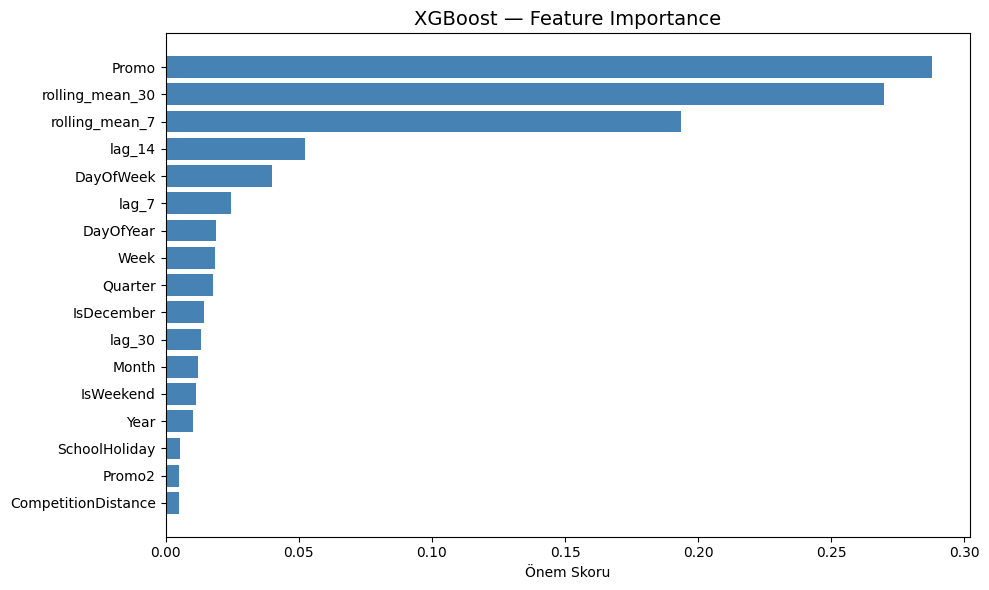

,Feature,Importance
1,Promo,0.287865
16,rolling_mean_30,0.269820
15,rolling_mean_7,0.193380
13,lag_14,0.052382
0,DayOfWeek,0.040032
12,lag_7,0.024522
9,DayOfYear,0.018911
7,Week,0.018469
8,Quarter,0.017949
11,IsDecember,0.014264


In [6]:
import matplotlib.pyplot as plt

# Hangi feature modeli en çok etkiliyor?
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.title('XGBoost — Feature Importance', fontsize=14)
plt.xlabel('Önem Skoru')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importance

In [7]:
from prophet import Prophet

# Prophet tek bir mağaza üzerinde çalışıyor
# En çok satan mağazayı seçiyoruz
store_id = 1

prophet_train = train[train['Store'] == store_id][['Date', 'Sales']].rename(
    columns={'Date': 'ds', 'Sales': 'y'}  # Prophet 'ds' ve 'y' sütun ismi bekliyor
)

prophet_test = test[test['Store'] == store_id][['Date', 'Sales']].rename(
    columns={'Date': 'ds', 'Sales': 'y'}
)

# Modeli kur ve eğit
prophet_model = Prophet(
    yearly_seasonality=True,   # Yıllık mevsimsellik
    weekly_seasonality=True,   # Haftalık mevsimsellik
    daily_seasonality=False    # Günlük mevsimsellik gerekmez
)

prophet_model.fit(prophet_train)
print("Prophet eğitimi tamamlandı!")

11:30:20 - cmdstanpy - INFO - Chain [1] start processing
11:30:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet eğitimi tamamlandı!


In [8]:
# Test dönemini tahmin et
future = prophet_model.make_future_dataframe(periods=len(prophet_test))
forecast = prophet_model.predict(future)

# Sadece test dönemini al
forecast_test = forecast.tail(len(prophet_test))

# Metrikleri hesapla
y_true = prophet_test['y'].values
y_pred = forecast_test['yhat'].values

mae_p = mean_absolute_error(y_true, y_pred)
rmse_p = np.sqrt(mean_squared_error(y_true, y_pred))
mape_p = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=== Prophet Sonuçları ===")
print(f"MAE:  {mae_p:.2f} £")
print(f"RMSE: {rmse_p:.2f} £")
print(f"MAPE: {mape_p:.2f} %")

=== Prophet Sonuçları ===
MAE:  688.78 £
RMSE: 832.77 £
MAPE: 16.10 %


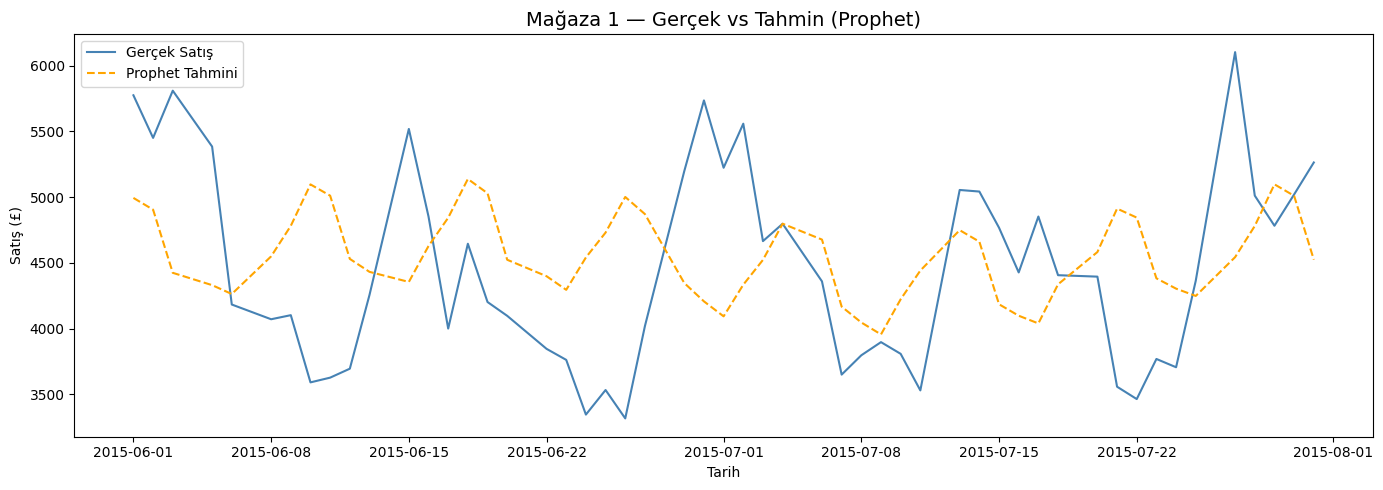

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prophet_test['ds'].values, y_true, label='Gerçek Satış', color='steelblue')
ax.plot(prophet_test['ds'].values, y_pred, label='Prophet Tahmini', color='orange', linestyle='--')

ax.set_title(f'Mağaza {store_id} — Gerçek vs Tahmin (Prophet)', fontsize=14)
ax.set_xlabel('Tarih')
ax.set_ylabel('Satış (£)')
ax.legend()
plt.tight_layout()
plt.show()

=== Model Karşılaştırması ===
                  Model    MAE    RMSE  MAPE (%)
XGBoost (tüm mağazalar) 725.65 1015.72     11.14
     Prophet (mağaza 1) 688.78  832.77     16.10


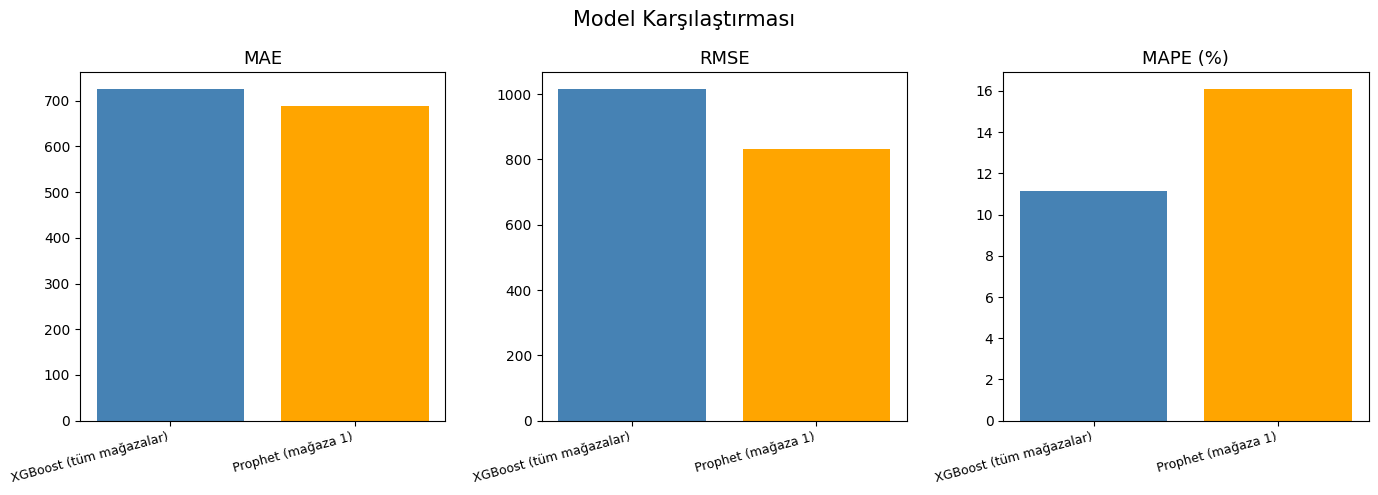

In [10]:
results = pd.DataFrame({
    'Model': ['XGBoost (tüm mağazalar)', 'Prophet (mağaza 1)'],
    'MAE': [725.65, 688.78],
    'RMSE': [1015.72, 832.77],
    'MAPE (%)': [11.14, 16.10]
})

print("=== Model Karşılaştırması ===")
print(results.to_string(index=False))

# Görsel karşılaştırma
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(['MAE', 'RMSE', 'MAPE (%)']):
    axes[i].bar(results['Model'], results[metric], color=['steelblue', 'orange'])
    axes[i].set_title(metric, fontsize=13)
    axes[i].set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=9)

plt.suptitle('Model Karşılaştırması', fontsize=15)
plt.tight_layout()
plt.show()